# Imports

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

import warnings
warnings.filterwarnings('ignore')

# loading dataset

In [3]:
df = pd.read_csv('used_cars.csv')

In [22]:
df.shape

(4009, 12)

In [4]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


# EDA and preprocessing

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


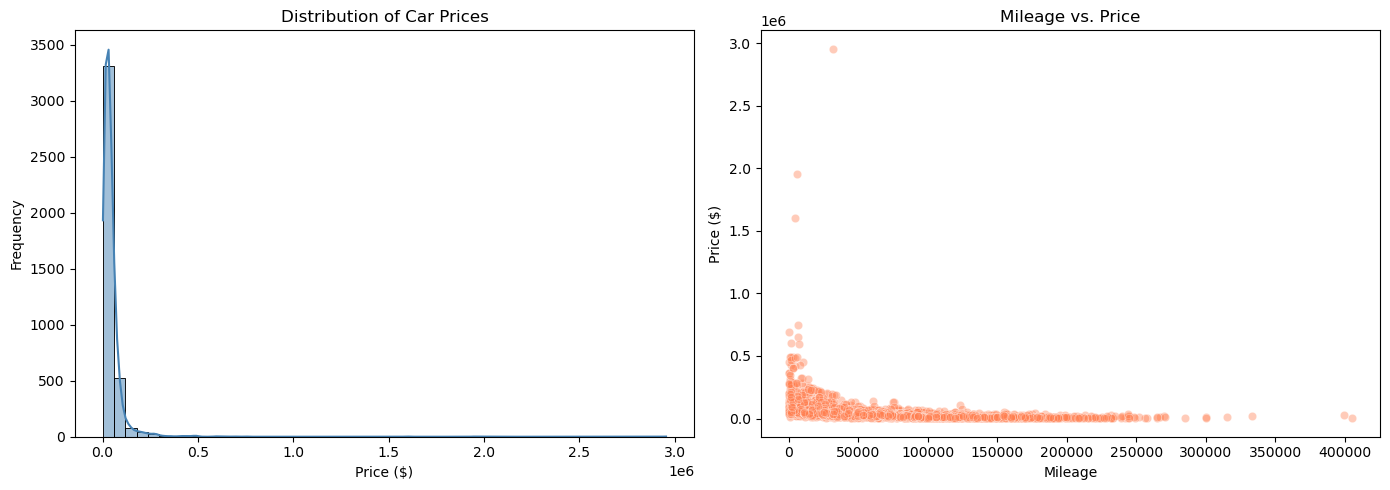

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['price'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Car Prices')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')

sns.scatterplot(x='milage', y='price', data=df, alpha=0.4, ax=axes[1], color='coral')
axes[1].set_title('Mileage vs. Price')
axes[1].set_xlabel('Mileage')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

In [6]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [10]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [7]:
df.isnull().sum().sum()

np.int64(879)

In [8]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

brand           object
model           object
model_year       int64
milage          object
fuel_type       object
engine          object
transmission    object
ext_col         object
int_col         object
accident        object
clean_title     object
price           object
dtype: object

In [14]:
categorical_columns = df.select_dtypes(include=['object']).columns
print("Categorical columns:", categorical_columns)

Categorical columns: Index(['brand', 'model', 'milage', 'fuel_type', 'engine', 'transmission',
       'ext_col', 'int_col', 'accident', 'clean_title', 'price'],
      dtype='object')


In [16]:
if df['price'].dtype == 'O':
    df['price'] = df['price'].str.replace('$', '').str.replace(',', '').astype(float)

if df['milage'].dtype == 'O':
    df['milage'] = df['milage'].str.replace(',', '').str.replace(' mi.', '').astype(float)

In [17]:
current_year = 2026
df['car_age'] = current_year - df['model_year'] 

In [18]:
df.drop('model_year', axis=1, inplace=True)

In [19]:
df.head()

,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,car_age
0,Ford,Utility Police Interceptor Base,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,13
1,Hyundai,Palisade SEL,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,5
2,Lexus,RX 350 RX 350,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598.0,4
3,INFINITI,Q50 Hybrid Sport,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0,11
4,Audi,Q3 45 S line Premium Plus,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0,5


In [20]:
most_common_fuel = df['fuel_type'].mode()[0]
df['fuel_type'].fillna(most_common_fuel, inplace=True)

df['accident'].fillna('None reported', inplace=True)

most_common_title = df['clean_title'].mode()[0]
df['clean_title'].fillna(most_common_title, inplace=True)

In [21]:
print("\nRemaining nulls after imputation:")
print(df.isnull().sum().sum())


Remaining nulls after imputation:
0


# Pipeline and splitting

In [25]:
X = df.drop('price', axis=1)
y = df['price']

In [26]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Building & Hyperparameter Tuning

In [28]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

In [29]:
param_distributions = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5, 10]
}

In [32]:
print("Starting hyperparameter tuning with 3-fold CV...")
random_search = RandomizedSearchCV(
    pipeline, 
    param_distributions=param_distributions, 
    n_iter=5, 
    cv=3,     
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

Starting hyperparameter tuning with 3-fold CV...


In [33]:
random_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'regressor__max_depth': [None, 10, ...], 'regressor__min_samples_split': [2, 5, ...], 'regressor__n_estimators': [50, 100, ...]}"
,n_iter,5
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [34]:
print("Tuning complete.")
print(f"Best Hyperparameters found: {random_search.best_params_}")

Tuning complete.
Best Hyperparameters found: {'regressor__n_estimators': 50, 'regressor__min_samples_split': 2, 'regressor__max_depth': None}


In [35]:
best_model = random_search.best_estimator_

# Evaluation

In [36]:
y_pred = best_model.predict(X_test)

In [37]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared Score: {r2:.4f}")

Root Mean Squared Error (RMSE): $134,659.37
R-squared Score: 0.1128


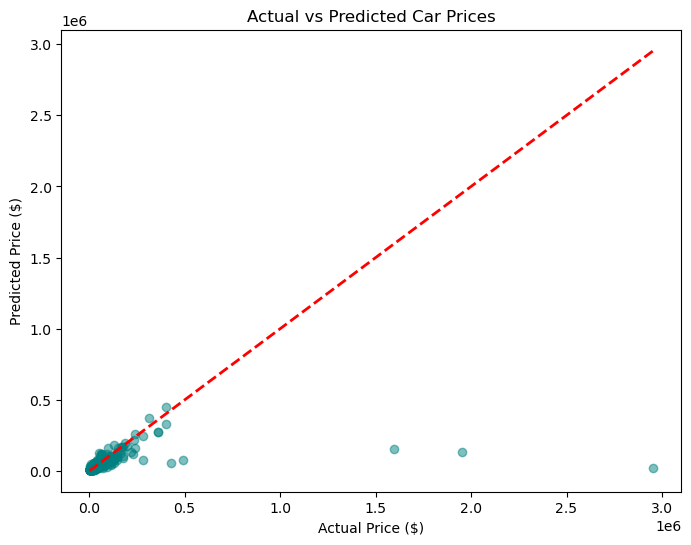

In [38]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted Car Prices')
plt.show()

# Model Export

In [40]:
model_filename = 'car_price_pipeline.pkl'
joblib.dump(best_model, model_filename)

print(f"Success! Model exported as: {model_filename}")

Success! Model exported as: car_price_pipeline.pkl
